In [2]:
import pandas as pd

df_clean = pd.read_excel(
    "../Data_understanding/Cleaned_Dataset.xlsx"
)

df_clean.head()

,Record_ID,Date_Time,State,Sector,Consumption_MWh,Peak_Demand_MW,Generation_MWh,Electricity_Price_USD_per_MWh,Renewable_Share_Pct,Weather_Index,Peak_Flag
0,103461,2024-05-24 04:00:00,California,Industrial,981.86,1139.91,1128.04,51.60,23.41,40.42,No
1,103959,2024-06-13 22:00:00,Texas,Industrial,1040.52,972.13,1047.89,52.96,27.82,67.81,No
2,100066,2024-01-03 17:00:00,Florida,Residential,920.08,895.03,969.66,58.09,35.91,45.49,No
3,102520,2024-04-14 23:00:00,Texas,Residential,686.13,758.59,699.00,50.12,37.10,33.45,No
4,100394,2024-01-17 09:00:00,California,Residential,1507.38,1745.83,1596.02,65.08,19.39,59.06,Yes


Target & Features

In [3]:
features = [
    "Consumption_MWh",
    "Generation_MWh",
    "Electricity_Price_USD_per_MWh",
    "Renewable_Share_Pct",
    "Weather_Index"
]

X = df_clean[features]
y = df_clean["Peak_Demand_MW"]

X.head()

,Consumption_MWh,Generation_MWh,Electricity_Price_USD_per_MWh,Renewable_Share_Pct,Weather_Index
0,981.86,1128.04,51.60,23.41,40.42
1,1040.52,1047.89,52.96,27.82,67.81
2,920.08,969.66,58.09,35.91,45.49
3,686.13,699.00,50.12,37.10,33.45
4,1507.38,1596.02,65.08,19.39,59.06


Define Target & Features

In [4]:
features = [
    "Consumption_MWh",
    "Generation_MWh",
    "Electricity_Price_USD_per_MWh",
    "Renewable_Share_Pct",
    "Weather_Index"
]

X = df_clean[features]
y = df_clean["Peak_Demand_MW"]

X.head()

,Consumption_MWh,Generation_MWh,Electricity_Price_USD_per_MWh,Renewable_Share_Pct,Weather_Index
0,981.86,1128.04,51.60,23.41,40.42
1,1040.52,1047.89,52.96,27.82,67.81
2,920.08,969.66,58.09,35.91,45.49
3,686.13,699.00,50.12,37.10,33.45
4,1507.38,1596.02,65.08,19.39,59.06


Train/Test Split

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (3992, 5)
Testing data: (999, 5)


Baseline Model

In [6]:
from sklearn.dummy import DummyRegressor

baseline_model = DummyRegressor(strategy="mean")

baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_test)

y_pred_baseline[:5]

array([1022.16194993, 1022.16194993, 1022.16194993, 1022.16194993,
       1022.16194993])

Evaluate the Baseline Model

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2_baseline = r2_score(y_test, y_pred_baseline)

print("Baseline MAE:", mae_baseline)
print("Baseline RMSE:", rmse_baseline)
print("Baseline R²:", r2_baseline)

Baseline MAE: 235.77030624834907
Baseline RMSE: 298.38893767559745
Baseline R²: -8.664894170418158e-05


Build the Random Forest Model

In [9]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

y_pred_rf[:5]

array([ 851.493 ,  532.322 , 1094.4013, 1177.5033, 1820.784 ])

Evaluate the Random Forest Model

In [10]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)
print("Random Forest R²:", r2_rf)

Random Forest MAE: 74.21188924338169
Random Forest RMSE: 97.83261963316954
Random Forest R²: 0.8924923030891946


Compare Baseline vs Random Forest

In [11]:
results = pd.DataFrame({
    "Model": ["Baseline", "Random Forest"],
    "MAE": [mae_baseline, mae_rf],
    "RMSE": [rmse_baseline, rmse_rf],
    "R2": [r2_baseline, r2_rf]
})

results

,Model,MAE,RMSE,R2
0,Baseline,235.770306,298.388938,-0.000087
1,Random Forest,74.211889,97.832620,0.892492


Feature Importance

In [12]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,Consumption_MWh,0.671223
1,Generation_MWh,0.218428
3,Renewable_Share_Pct,0.048929
2,Electricity_Price_USD_per_MWh,0.038471
4,Weather_Index,0.022948


Visualize Feature Importance

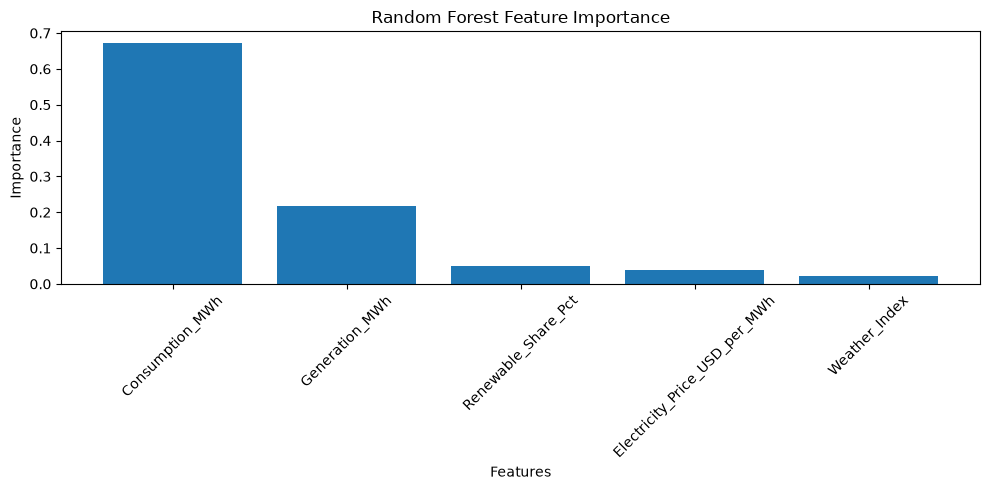

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xticks(rotation=45)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()

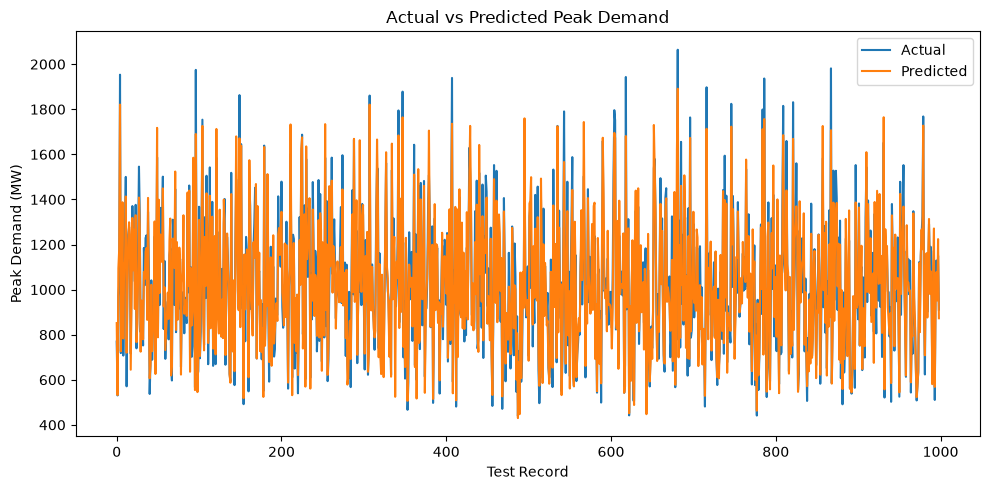

In [14]:
plt.figure(figsize=(10, 5))

plt.plot(
    y_test.values,
    label="Actual"
)

plt.plot(
    y_pred_rf,
    label="Predicted"
)

plt.xlabel("Test Record")
plt.ylabel("Peak Demand (MW)")
plt.title("Actual vs Predicted Peak Demand")
plt.legend()

plt.tight_layout()
plt.show()

Residual / Error Analysis

In [15]:
residuals = y_test - y_pred_rf

print("Mean Residual:", residuals.mean())
print("Minimum Residual:", residuals.min())
print("Maximum Residual:", residuals.max())

Mean Residual: -0.6527213332644276
Minimum Residual: -672.3532000000005
Maximum Residual: 465.74709999999993


Residual Plot

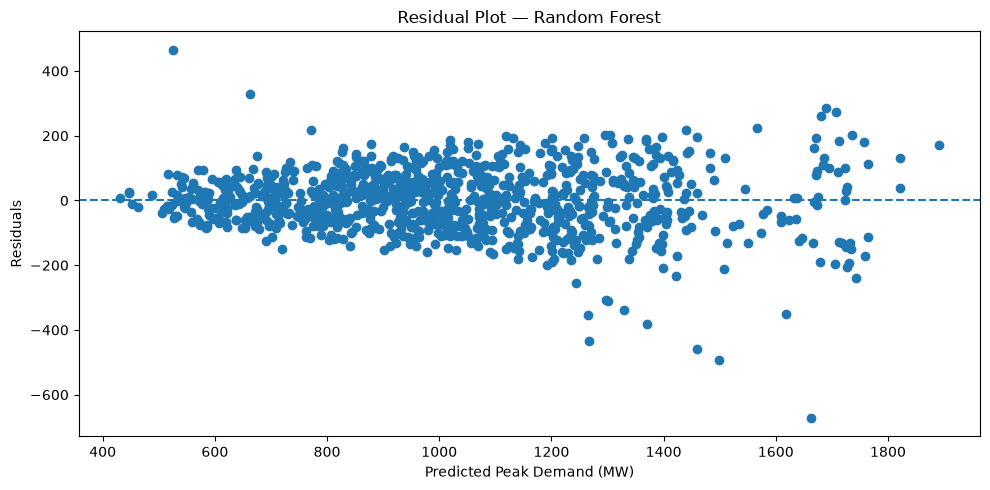

In [16]:
plt.figure(figsize=(10, 5))

plt.scatter(
    y_pred_rf,
    residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Peak Demand (MW)")
plt.ylabel("Residuals")
plt.title("Residual Plot — Random Forest")

plt.tight_layout()
plt.show()

Prepare Data for Forecasting

In [17]:
df_forecast = df_clean.copy()

df_forecast["Date_Time"] = pd.to_datetime(
    df_forecast["Date_Time"]
)

df_forecast = df_forecast.set_index("Date_Time")

daily_forecast = df_forecast.resample("D")[
    "Peak_Demand_MW"
].mean()

daily_forecast.head()

Date_Time
2024-01-01     996.522083
2024-01-02    1164.275200
2024-01-03    1092.723750
2024-01-04    1078.490870
2024-01-05    1063.859583
Freq: D, Name: Peak_Demand_MW, dtype: float64

Train/Test Split for Forecasting

In [18]:
split_index = int(len(daily_forecast) * 0.8)

train_forecast = daily_forecast.iloc[:split_index]
test_forecast = daily_forecast.iloc[split_index:]

print("Training observations:", len(train_forecast))
print("Testing observations:", len(test_forecast))

Training observations: 167
Testing observations: 42


Build the Forecasting Model

In [21]:
%pip install statsmodels

   ---------------------------------------- 0.0/11.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.4 MB 960.0 kB/s eta 0:00:12
   ---------------------------------------- 0.1/11.4 MB 1.8 MB/s eta 0:00:07
    --------------------------------------- 0.3/11.4 MB 2.2 MB/s eta 0:00:05
   - -------------------------------------- 0.3/11.4 MB 2.0 MB/s eta 0:00:06
   - -------------------------------------- 0.5/11.4 MB 2.3 MB/s eta 0:00:05
   - -------------------------------------- 0.6/11.4 MB 2.2 MB/s eta 0:00:05
   -- ------------------------------------- 0.6/11.4 MB 2.0 MB/s eta 0:00:06
   -- ------------------------------------- 0.7/11.4 MB 2.1 MB/s eta 0:00:06
   -- ------------------------------------- 0.8/11.4 MB 1.8 MB/s eta 0:00:06
   -- ------------------------------------- 0.8/11.4 MB 1.8 MB/s eta 0:00:06
   --- ------------------------------------ 1.0/11.4 MB 1.8 MB/s eta 0:00:06
   --- ------------------------------------ 1.0/11.4 MB 1.9 MB/s eta 0:00:06
   -


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(
    train_forecast,
    order=(1, 1, 1)
)

arima_fit = arima_model.fit()

arima_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:         Peak_Demand_MW   No. Observations:                  167
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -962.441
Date:                Tue, 15 Sep 2026   AIC                           1930.882
Time:                        23:42:06   BIC                           1940.217
Sample:                    01-01-2024   HQIC                          1934.671
                         - 06-15-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1510      0.076      1.999      0.046       0.003       0.299
ma.L1         -0.9980      0.184     -5.427      0.000      -1.359      -0.638
sigma2      6185.9180   1225.343      5.048      0.000    3784.290    8587.546
===================================================================================
Ljung-Box (L1) (Q):                   0.22   Jarque-Bera (JB):                22.53
Prob(Q):                              0.64   Prob(JB):                         0.00
Heteroskedasticity (H):               0.70   Skew:                             0.41
Prob(H) (two-sided):                  0.19   Kurtosis:                         4.61
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Fit the ARIMA Model

In [23]:
arima_model = ARIMA(
    train_forecast,
    order=(1, 1, 1)
)

arima_fit = arima_model.fit()

print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:         Peak_Demand_MW   No. Observations:                  167
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -962.441
Date:                Tue, 15 Sep 2026   AIC                           1930.882
Time:                        23:42:41   BIC                           1940.217
Sample:                    01-01-2024   HQIC                          1934.671
                         - 06-15-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1510      0.076      1.999      0.046       0.003       0.299
ma.L1         -0.9980      0.184     -5.427      0.000      -1.359      -0.638
sigma2      6185.9180   1225.343      5.048      0.0

Generate ARIMA Forecast

In [24]:
forecast = arima_fit.forecast(
    steps=len(test_forecast)
)

forecast.head()

2024-06-16    1013.419076
2024-06-17    1019.774439
2024-06-18    1020.734136
2024-06-19    1020.879055
2024-06-20    1020.900939
Freq: D, Name: predicted_mean, dtype: float64

Evaluate the ARIMA Forecast

In [25]:
mae_arima = mean_absolute_error(
    test_forecast,
    forecast
)

rmse_arima = np.sqrt(
    mean_squared_error(
        test_forecast,
        forecast
    )
)

r2_arima = r2_score(
    test_forecast,
    forecast
)

print("ARIMA MAE:", mae_arima)
print("ARIMA RMSE:", rmse_arima)
print("ARIMA R²:", r2_arima)

ARIMA MAE: 66.03456444001759
ARIMA RMSE: 92.93025291404132
ARIMA R²: 0.0022244377379602165


Actual vs Forecasted Peak Demand

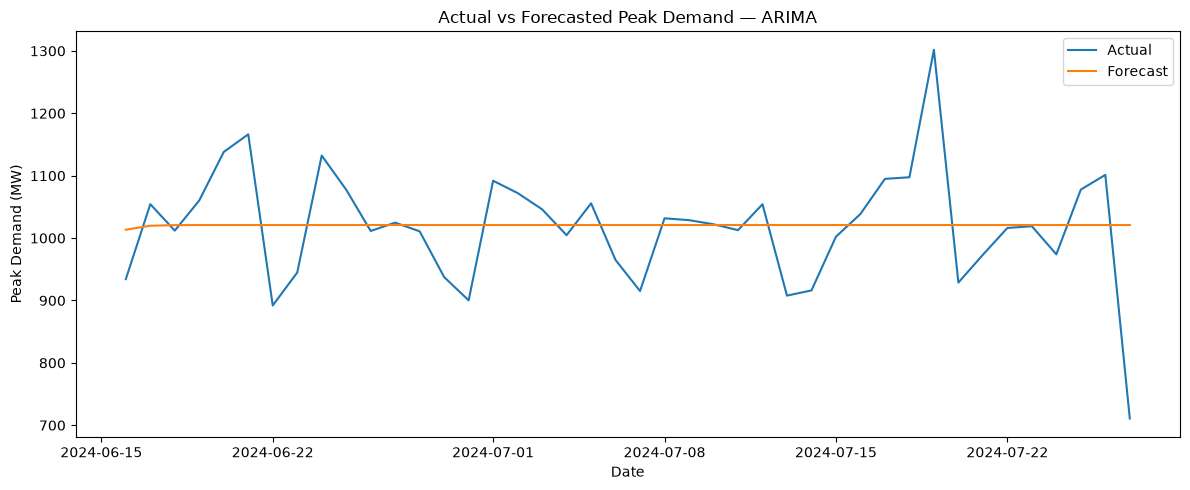

In [26]:
plt.figure(figsize=(12, 5))

plt.plot(
    test_forecast.index,
    test_forecast,
    label="Actual"
)

plt.plot(
    test_forecast.index,
    forecast,
    label="Forecast"
)

plt.xlabel("Date")
plt.ylabel("Peak Demand (MW)")
plt.title("Actual vs Forecasted Peak Demand — ARIMA")
plt.legend()

plt.tight_layout()
plt.show()

Final ML & Forecasting Comparison

In [27]:
final_results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Random Forest",
        "ARIMA"
    ],
    "MAE": [
        mae_baseline,
        mae_rf,
        mae_arima
    ],
    "RMSE": [
        rmse_baseline,
        rmse_rf,
        rmse_arima
    ],
    "R2": [
        r2_baseline,
        r2_rf,
        r2_arima
    ]
})

final_results

,Model,MAE,RMSE,R2
0,Baseline,235.770306,298.388938,-0.000087
1,Random Forest,74.211889,97.832620,0.892492
2,ARIMA,66.034564,92.930253,0.002224
